# Fitting a Gaussian to a laser beam image

We have a camera image of a 650 nm laser beam (`beam_frame_2026-07-06.npy`). A "perfect" laser beam
should look like a 2D Gaussian (a smooth round hill). Ours clearly doesn't, so the plan is:

1. **Fit the best possible Gaussian** to the image anyway.
2. **Subtract the fit from the data.** Whatever is left over (the *residuals*) is exactly how the
   real beam differs from an ideal one.

We also try a "super-Gaussian" — a Gaussian with an adjustable shape knob — to check whether the
beam is flatter or pointier than a true Gaussian.

**One caution before we start:** the brightest pixel is 248 out of a max of 255 (this is an 8-bit
camera). We're right below clipping, so the very top of the peak might be slightly distorted. For a
cleaner measurement, retake the image with the peak around 70% of max.

In [3]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

frame = np.load('../calibrations/calibrated_camera_settings_2026-07-06_18-47-52.npy').astype(float)
print(f"image size: {frame.shape}")
print(f"pixel values: {frame.min():.0f} to {frame.max():.0f} (camera max is 255)")
print(f"pixels at 255 (clipped): {(frame == 255).sum()}")

image size: (1536, 2048)
pixel values: 0 to 248 (camera max is 255)
pixels at 255 (clipped): 0


## Step 1: Crop to just the beam

Most of the image is dark background, which slows the fit down without adding information.
We keep only the region where the signal is above 10 counts, plus an 80-pixel border so the fit
can still "see" the background level.

In [4]:
# Find rows and columns that contain any signal above 10 counts
mask = frame > 10
rows = np.any(mask, axis=1)
cols = np.any(mask, axis=0)
r0, r1 = np.where(rows)[0][[0, -1]]   # first and last row with signal
c0, c1 = np.where(cols)[0][[0, -1]]   # first and last column with signal

# Add an 80 px margin on every side (without going outside the image)
pad = 80
r0 = max(r0 - pad, 0); r1 = min(r1 + pad, frame.shape[0] - 1)
c0 = max(c0 - pad, 0); c1 = min(c1 + pad, frame.shape[1] - 1)

img = frame[r0:r1 + 1, c0:c1 + 1]
print(f"cropped from {frame.shape} down to {img.shape}")

# X and Y coordinate of every pixel in the crop (X = column, Y = row)
Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]

cropped from (1536, 2048) down to (562, 637)


## Step 2: Fit a 2D Gaussian

A 2D Gaussian "hill" has 7 numbers that describe it:

| parameter | meaning |
|---|---|
| $A$ | peak height (counts) |
| $x_0, y_0$ | where the center is |
| $\sigma_{x'}, \sigma_{y'}$ | how wide it is along its two axes |
| $\theta$ | rotation angle of those axes |
| offset | background level |

Why the rotation angle? If the beam is elliptical (wider one way than the other), there's no reason
its long axis lines up with the camera's x-axis. So we let the ellipse rotate: we measure distances
along rotated coordinates $x'$ and $y'$ instead of plain $x$ and $y$:

$$f(x,y) = \mathrm{offset} + A\,\exp\!\left[-\left(\frac{x'^2}{2\sigma_{x'}^2} + \frac{y'^2}{2\sigma_{y'}^2}\right)\right]$$

$$x' = (x-x_0)\cos\theta + (y-y_0)\sin\theta,\qquad y' = -(x-x_0)\sin\theta + (y-y_0)\cos\theta$$

This is also why we fit the whole 2D image at once instead of fitting 1D slices along x and y:
a horizontal or vertical slice through a *rotated* ellipse mixes the two axes together and gives
you the wrong widths.

`scipy.optimize.curve_fit` does the fitting: we give it the model function and a rough starting
guess, and it adjusts the 7 parameters until the model matches the data as closely as possible
(least squares).

In [5]:
def gauss2d(coords, A, x0, y0, sx, sy, theta, off):
    """Rotated 2D elliptical Gaussian."""
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    # rotate coordinates so x', y' line up with the ellipse axes
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    return off + A * np.exp(-(xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)))

# Starting guesses: use the image's center of mass and spread.
# curve_fit needs a reasonable starting point or it can wander off.
tot = img.sum()
x0g = (X * img).sum() / tot                       # center of mass, x
y0g = (Y * img).sum() / tot                       # center of mass, y
sxg = np.sqrt(((X - x0g)**2 * img).sum() / tot)   # rough width, x
syg = np.sqrt(((Y - y0g)**2 * img).sum() / tot)   # rough width, y
p0 = [img.max(), x0g, y0g, sxg, syg, 0.0, 0.0]

# curve_fit wants 1D arrays, so flatten the image and coordinates
xy = np.vstack([X.ravel(), Y.ravel()])
popt, pcov = curve_fit(gauss2d, xy, img.ravel(), p0=p0)
perr = np.sqrt(np.diag(pcov))   # 1-sigma uncertainty on each parameter

fit = gauss2d(xy, *popt).reshape(img.shape)
resid = img - fit               # what the Gaussian CAN'T explain

# R^2 = fraction of the image's variation the fit explains (1.0 = perfect)
ss_tot = ((img - img.mean())**2).sum()
r2_g = 1 - (resid**2).sum() / ss_tot

A, x0, y0, sx, sy, th, off = popt
sx, sy = abs(sx), abs(sy)
th_deg = np.degrees(th) % 180   # angle only matters between 0 and 180 deg

names = ['A', 'x0', 'y0', 'sigma_x\'', 'sigma_y\'', 'theta (deg)', 'offset']
for n_, v, e in zip(names, [A, x0, y0, sx, sy, th_deg, off], perr):
    print(f"{n_:12s} = {v:9.3f} ± {e:.3f}")
print(f"\ncenter in the full (uncropped) image: ({x0 + c0:.1f}, {y0 + r0:.1f}) px")
print(f"ellipticity (long axis / short axis) = {max(sx, sy) / min(sx, sy):.3f}")
print(f"R^2 = {r2_g:.4f}")

A            =   229.691 ± 0.087
x0           =   335.483 ± 0.024
y0           =   285.841 ± 0.026
sigma_x'     =    72.245 ± 0.029
sigma_y'     =    61.063 ± 0.024
theta (deg)  =    59.589 ± 0.002
offset       =     2.393 ± 0.015

center in the full (uncropped) image: (768.5, 769.8) px
ellipticity (long axis / short axis) = 1.183
R^2 = 0.9703


## Step 3: Is the beam flatter or pointier than a Gaussian?

A **super-Gaussian** is a Gaussian with one extra parameter $n$ that controls the shape:

$$f = \mathrm{offset} + A\,\exp\!\left[-\left(\frac{x'^2}{2\sigma_{x'}^2} + \frac{y'^2}{2\sigma_{y'}^2}\right)^{\!n}\right]$$

- $n = 1$: exactly a Gaussian
- $n > 1$: flat-top (like a mesa)
- $n < 1$: sharp peak with fat tails (like a tent with wide skirts)

If the fit chooses $n$ far from 1, the beam's basic shape is non-Gaussian. If $n$ stays near 1 and
the fit barely improves, the problem isn't the overall shape — it's localized structure.

In [6]:
def supergauss2d(coords, A, x0, y0, sx, sy, theta, off, n):
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    q = xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)
    return off + A * np.exp(-q**n)

# Start from the Gaussian fit's answer, with n = 1
p0_sg = list(popt) + [1.0]
popt_sg, pcov_sg = curve_fit(supergauss2d, xy, img.ravel(), p0=p0_sg, maxfev=20000)
fit_sg = supergauss2d(xy, *popt_sg).reshape(img.shape)
r2_sg = 1 - ((img - fit_sg)**2).sum() / ss_tot

n_exp = popt_sg[-1]
print(f"super-Gaussian exponent n = {n_exp:.3f} ± {np.sqrt(np.diag(pcov_sg))[-1]:.3f}")
print(f"R^2 = {r2_sg:.4f}  (plain Gaussian was {r2_g:.4f})")
if n_exp < 1:
    print("n < 1: slightly sharper peak and fatter tails than a Gaussian")
else:
    print("n > 1: flatter top than a Gaussian")

super-Gaussian exponent n = 0.886 ± 0.001
R^2 = 0.9714  (plain Gaussian was 0.9703)
n < 1: slightly sharper peak and fatter tails than a Gaussian


## Step 4: Plot everything

Four panels:
- **Data** — the cropped beam image
- **Fit** — the best Gaussian
- **Residuals** — data minus fit. Red = beam is brighter than the Gaussian there, blue = dimmer.
  The black ellipse marks the fitted beam's 2σ outline for reference.
- **1D cuts** — horizontal and vertical slices through the beam center, data vs. fit

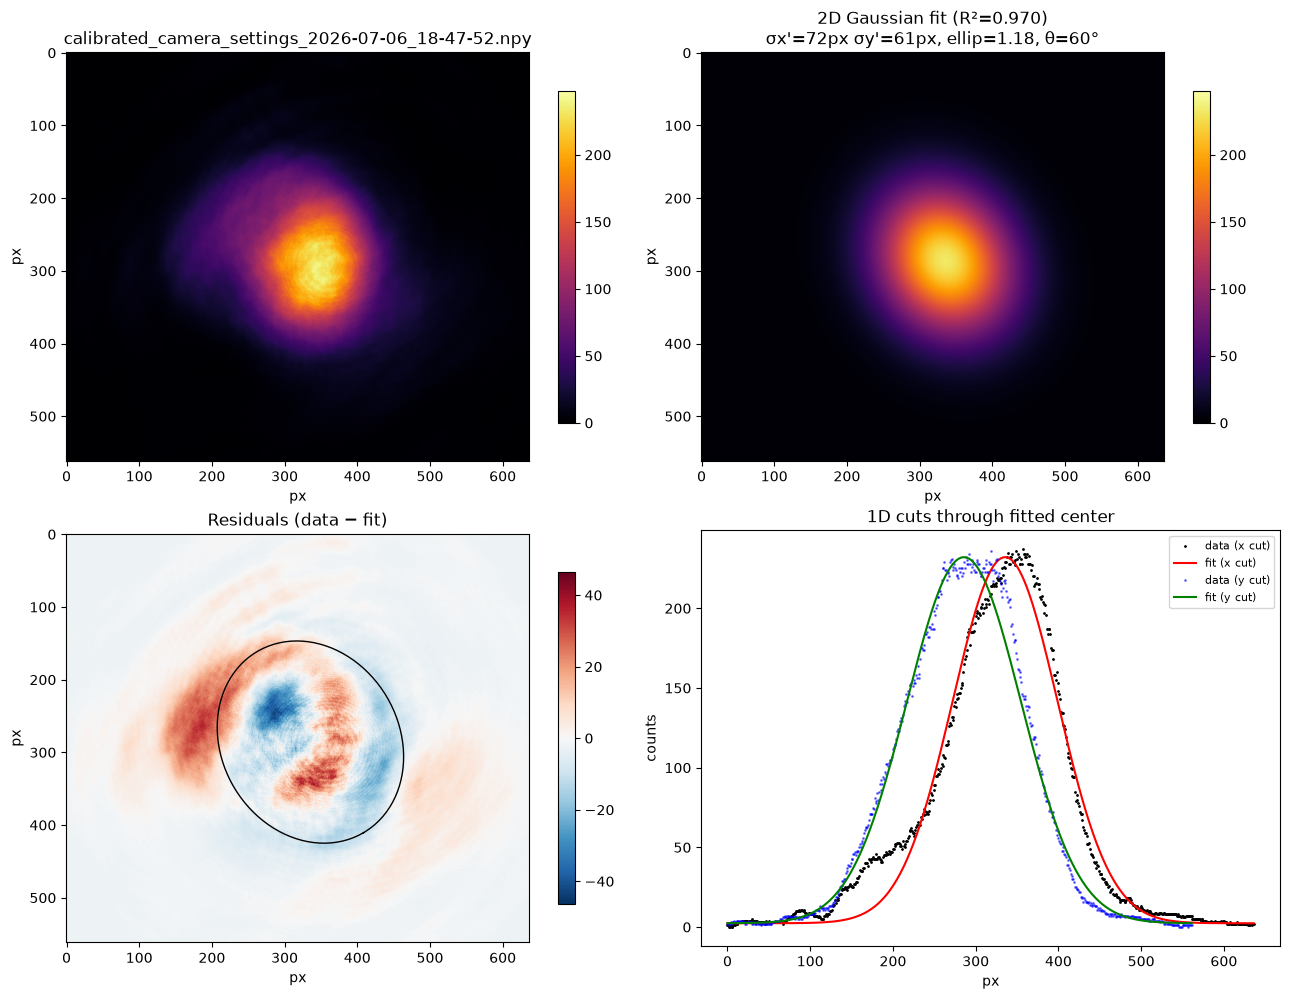

residuals span -46 to 42 counts, i.e. up to 20% of the 230-count peak


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

im0 = axs[0, 0].imshow(img, cmap='inferno')
axs[0, 0].set_title('calibrated_camera_settings_2026-07-06_18-47-52.npy'); plt.colorbar(im0, ax=axs[0, 0], shrink=0.8)

im1 = axs[0, 1].imshow(fit, cmap='inferno', vmin=im0.get_clim()[0], vmax=im0.get_clim()[1])
axs[0, 1].set_title(f"2D Gaussian fit (R²={r2_g:.3f})\n"
                    f"σx'={sx:.0f}px σy'={sy:.0f}px, ellip={max(sx,sy)/min(sx,sy):.2f}, θ={th_deg:.0f}°")
plt.colorbar(im1, ax=axs[0, 1], shrink=0.8)

vmax = np.abs(resid).max()
im2 = axs[1, 0].imshow(resid, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 0].set_title('Residuals (data − fit)'); plt.colorbar(im2, ax=axs[1, 0], shrink=0.8)
# draw the fitted ellipse at 2 sigma
t = np.linspace(0, 2 * np.pi, 200)
ex = x0 + 2 * sx * np.cos(t) * np.cos(th) - 2 * sy * np.sin(t) * np.sin(th)
ey = y0 + 2 * sx * np.cos(t) * np.sin(th) + 2 * sy * np.sin(t) * np.cos(th)
axs[1, 0].plot(ex, ey, 'k-', lw=1)

iy, ix = int(round(y0)), int(round(x0))
axs[1, 1].plot(img[iy, :], 'k.', ms=2, label='data (x cut)')
axs[1, 1].plot(fit[iy, :], 'r-', label='fit (x cut)')
axs[1, 1].plot(img[:, ix], 'b.', ms=2, alpha=0.5, label='data (y cut)')
axs[1, 1].plot(fit[:, ix], 'g-', label='fit (y cut)')
axs[1, 1].set_title('1D cuts through fitted center')
axs[1, 1].set_xlabel('px'); axs[1, 1].set_ylabel('counts'); axs[1, 1].legend(fontsize=8)

for ax in axs.flat[:3]:
    ax.set_xlabel('px'); ax.set_ylabel('px')
plt.tight_layout()
plt.show()

print(f"residuals span {resid.min():.0f} to {resid.max():.0f} counts, "
      f"i.e. up to {100 * np.abs(resid).max() / A:.0f}% of the {A:.0f}-count peak")

## Step 5: What did we learn?

The Gaussian explains ~97% of the image (R² = 0.97), so the beam is *mostly* Gaussian. But the
residual map isn't random noise — it has clear structure, and each feature tells us something
physical:

- **A bright blob up and to the left of the peak** (big red patch in the residuals). There's a
  second, weaker spot of light riding on the main beam — often a stray reflection off a lens or
  window surface, or light clipping on an edge somewhere.
- **A red/blue pair straddling the center**: the beam's peak isn't in the middle of its overall
  light distribution — the beam is lopsided (skewed).
- **Faint concentric rings**: alternating red/blue circles are diffraction rings, usually from the
  beam grazing an aperture edge or hitting a dust speck.
- **The beam is elliptical, not round**: 1.18× wider along one axis, and that axis is rotated
  ~150° from horizontal. Rotated ellipticity like this often points to astigmatism in the
  collimating optics.
- **n = 0.89 (slightly less than 1)**: the profile is a bit peakier than Gaussian with fatter
  tails — but since R² barely improved (0.9703 → 0.9714), the shape knob isn't the real story.
  The localized features above are.

### If you want to go further
- **ISO 11146 second-moment widths (D4σ)** — the industry-standard beam size, computed straight
  from the image without assuming any model
- **Skewness/kurtosis along each axis** — puts numbers on the lopsidedness
- **Hermite-Gauss decomposition** — expresses the beam as a sum of laser cavity modes, telling
  you how much power is in modes other than the fundamental
- **Retake the frame with the peak at ~70% of 255** to rule out saturation effects

## Step 6: Estimate Beam Diameter

D_major = 0.997 mm, D_minor = 0.843 mm, geo mean = 0.917 mm, expansion needed = 2.18x


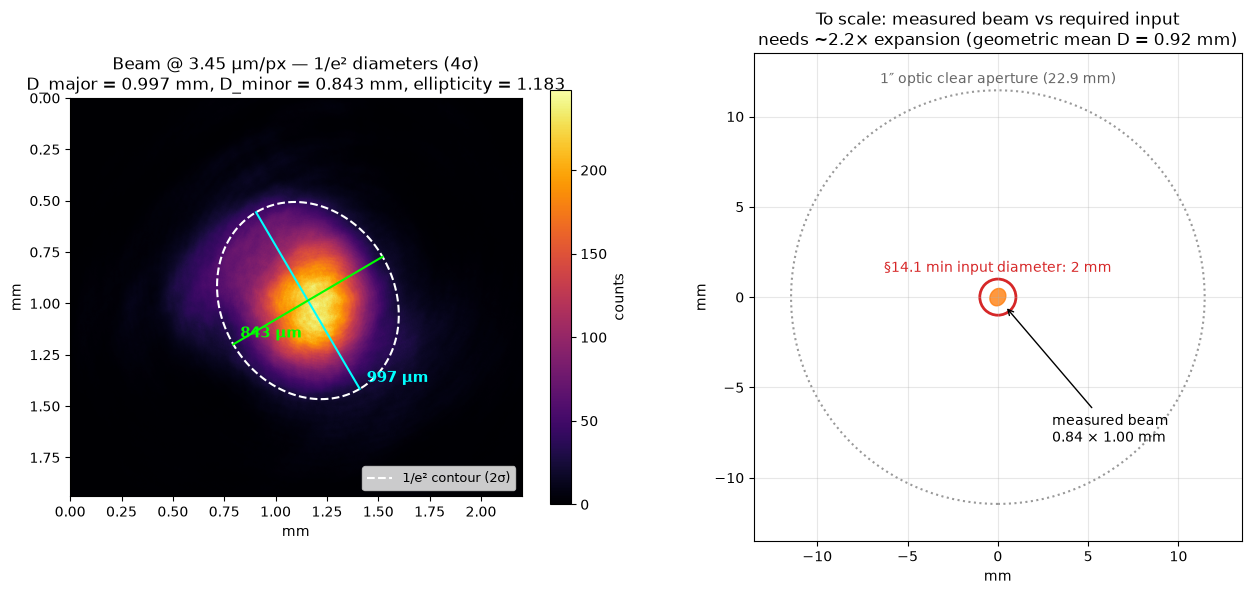

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
 
PX = 3.45e-3  # mm per pixel
 
frame = np.load('../calibrations/calibrated_camera_settings_2026-07-06_18-47-52.npy').astype(float)
mask = frame > 10
r0, r1 = np.where(np.any(mask, axis=1))[0][[0, -1]]
c0, c1 = np.where(np.any(mask, axis=0))[0][[0, -1]]
pad = 80
r0 = max(r0 - pad, 0); r1 = min(r1 + pad, frame.shape[0] - 1)
c0 = max(c0 - pad, 0); c1 = min(c1 + pad, frame.shape[1] - 1)
img = frame[r0:r1 + 1, c0:c1 + 1]
Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
 
def gauss2d(coords, A, x0, y0, sx, sy, theta, off):
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    return off + A * np.exp(-(xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)))
 
tot = img.sum()
x0g = (X * img).sum() / tot; y0g = (Y * img).sum() / tot
sxg = np.sqrt(((X - x0g)**2 * img).sum() / tot)
syg = np.sqrt(((Y - y0g)**2 * img).sum() / tot)
xy = np.vstack([X.ravel(), Y.ravel()])
popt, _ = curve_fit(gauss2d, xy, img.ravel(), p0=[img.max(), x0g, y0g, sxg, syg, 0, 0])
A, x0, y0, sx, sy, th, off = popt
sx, sy = abs(sx), abs(sy)
 
s_maj, s_min = max(sx, sy), min(sx, sy)
th_maj = th if sx >= sy else th + np.pi / 2   # angle of major axis
D_maj, D_min = 4 * s_maj * PX, 4 * s_min * PX
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
 
# ---- Panel 1: beam in physical units with 1/e^2 ellipse ----
extent = [0, img.shape[1] * PX, img.shape[0] * PX, 0]
im = ax1.imshow(img, cmap='inferno', extent=extent)
plt.colorbar(im, ax=ax1, shrink=0.85, label='counts')
 
t = np.linspace(0, 2 * np.pi, 300)
ex = (x0 + 2 * s_maj * np.cos(t) * np.cos(th_maj) - 2 * s_min * np.sin(t) * np.sin(th_maj)) * PX
ey = (y0 + 2 * s_maj * np.cos(t) * np.sin(th_maj) + 2 * s_min * np.sin(t) * np.cos(th_maj)) * PX
ax1.plot(ex, ey, 'w--', lw=1.5, label='1/e² contour (2σ)')
 
# major / minor axis lines with labels
for s_, ang, D_, col in [(s_maj, th_maj, D_maj, 'cyan'),
                         (s_min, th_maj + np.pi / 2, D_min, 'lime')]:
    xa = np.array([x0 - 2 * s_ * np.cos(ang), x0 + 2 * s_ * np.cos(ang)]) * PX
    ya = np.array([y0 - 2 * s_ * np.sin(ang), y0 + 2 * s_ * np.sin(ang)]) * PX
    ax1.plot(xa, ya, color=col, lw=1.5)
    ax1.annotate(f'{D_ * 1e3:.0f} µm', xy=(xa[1], ya[1]), color=col,
                 fontsize=11, fontweight='bold',
                 xytext=(5, 5), textcoords='offset points')
 
ax1.set_xlabel('mm'); ax1.set_ylabel('mm')
ax1.set_title(f'Beam @ 3.45 µm/px — 1/e² diameters (4σ)\n'
              f'D_major = {D_maj:.3f} mm, D_minor = {D_min:.3f} mm, '
              f'ellipticity = {s_maj / s_min:.3f}')
ax1.legend(loc='lower right', fontsize=9)
 
# ---- Panel 2: to-scale comparison vs design requirement ----
ax2.set_aspect('equal')
design_D = 2   # mm, 1/e2 diameter required by the 3-axicon (sec 17) design
ca_1in = 22.9    # mm, 1 inch clear aperture
 
circ = plt.Circle((0, 0), ca_1in / 2, fill=False, color='0.6', ls=':', lw=1.5)
ax2.add_patch(circ)
circ2 = plt.Circle((0, 0), design_D / 2, fill=False, color='tab:red', lw=2)
ax2.add_patch(circ2)
exb = (2 * s_maj * np.cos(t) * np.cos(th_maj) - 2 * s_min * np.sin(t) * np.sin(th_maj)) * PX
eyb = (2 * s_maj * np.cos(t) * np.sin(th_maj) + 2 * s_min * np.sin(t) * np.cos(th_maj)) * PX
ax2.fill(exb, eyb, color='tab:orange', alpha=0.8)
 
ax2.annotate('measured beam\n0.84 × 1.00 mm', xy=(0.4, -0.5), xytext=(3, -8),
             fontsize=10, arrowprops=dict(arrowstyle='->'))
ax2.text(0, design_D / 2 + 0.4, f'§14.1 min input diameter: {design_D} mm',
         color='tab:red', ha='center', fontsize=10)
ax2.text(0, ca_1in / 2 + 0.4, '1″ optic clear aperture (22.9 mm)',
         color='0.4', ha='center', fontsize=10)
ax2.set_xlim(-13.5, 13.5); ax2.set_ylim(-13.5, 13.5)
ax2.set_xlabel('mm'); ax2.set_ylabel('mm')
ax2.set_title(f'To scale: measured beam vs required input\n'
              f'needs ~{design_D / np.sqrt(D_maj * D_min):.1f}× expansion '
              f'(geometric mean D = {np.sqrt(D_maj * D_min):.2f} mm)')
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('beam_diameter_vs_design.png', dpi=140, bbox_inches='tight')
print(f"D_major = {D_maj:.3f} mm, D_minor = {D_min:.3f} mm, "
      f"geo mean = {np.sqrt(D_maj * D_min):.3f} mm, "
      f"expansion needed = {design_D / np.sqrt(D_maj * D_min):.3f}x")